# Laboratorio 13

## Distribuciones de probabilidad y ley débil de los grandes números

Este Jupyter Notebook, tiene contenido el código para estudiar las tres distribuciones de probabilidades continuas, en las que podemos enumerar:

1. Distribución uniforme.
2. Distribución exponencial.
3. Distribución normal o Gaussiana.

En este laboratorio se hace particular énfasis en que se realizarán derivaciones analíticas y simulaciones con numpy.random. Además del archivo del Jupyter Notebook, se procederá a entregar la copia en PDF del archivo para observar el resultado de su ejecución.

### Sección de Desarrollo Algebraico de las Distribuciones

En esta sección, procedemos a armar con algunas celdas de Markdown, algunos de los desarrollos algebraicos que son necesarios para la ejecución de este laboratorio.

##### Distribución Uniforme $X \sim U(a,b)$

Donde tenemos la función de densidad de probabilidad, la cual se encuentra dada por:

$$p(x) = \frac{1}{b-a}, \quad a \le x \le b$$

Tenemos el valor esperado $E[X]$

$$E[X] = \int{a}^{b} x \frac{1}{b-a} dx = \frac{1}{b-a} \left[\frac{x^2}{2}\right]_{a}^{b}$$
$$E[X] = \frac{1}{b-a} \left( \frac{b^2 - a^2}{2} \right) = \frac{(b-a)(b+a)}{2(b-a)} = \frac{a+b}{2}$$

Para la varianza $Var(X)$$

Procedemos a calcular el segundo momento $E[X^2]$:

El cual se encuentra dado por:

$$E[X^2] = \int_{a}^{b} x^2 \frac{1}{b-a} dx = \frac{1}{b-a} \left[\frac{x^3}{3} \right]_{a}^{b} = \frac{b^3 - a^3}{3(b-a)}$$

Y ahora procedemos a factorizar la diferencia de cubos, la cual se encuentra dada por:

$$E[X^2] = \frac{b^2 + ab + a^2}{3}$$

Y aplicando la identidad $Var(X) = E[X^2] - E[X]^2$:
$$Var(X) = \frac{b^2 + ab + a^2}{3} - \left(\frac{a+b}{2}\right)^2 = \frac{b^2 + ab + a^2}{3} - \frac{a^2+2ab+b^2}{4}$$

Y al homogenizar fracciones, nos queda ahora que:

$$Var(X) = \frac{4b^2 + 4ab + 4a^2 - 3a^2 - 6ab - 3b^2}{12} = \frac{a^2 - 2ab + b^2}{12} = \frac{(b-a)^2}{12}$$

##### Sección de la Distribución Exponencial $X \sim Exp(\lambda)$

En esta sección, dada la función de densidad de probabilidad:

$$p(x) = \lambda e^{-\lambda x}, \quad x \ge 0$$

Procedemos a calcular el valor esperado $E[X]$

$$E[X] = \int_{0}^{\infty} x \lambda e^{-\lambda x} dx$$

Y ala hora de aplicar integración por partes donde tenemos ahora que:

$$u = x \implies du = dx$$
$$dv = \lambda e^{-\lambda x} dx \implies v = -e^{-\lambda x}$$

Y tenemos ahora que esto nos queda de la forma:

$$E[X] = \left[-x e^{-\lambda x} \right]_{0}^{\infty} - \int_{0}^{\infty} (-e^{-\lambda x}) dx$$

Y finalmente, tenemos el primer término que se evalua en $0$ por el límite cuando $x \to \infty$. Evaluamos la integral restante:

$$E[X] = \left[-\frac{1}{\lambda} e^{-lambda x} \right]_{0}^{\infty} = 0 - \left( -\frac{1}{\lambda} \right) = \frac{1}{\lambda}$$

Y finalmente, procedemos a calcular la varianza $Var(X)$:

Y tenemos ahora que $E[X^2]$:

$$E[X^2] = \left[-x^2] e^{-\lambda x} \right]_{0}^{\infty} + 2 \int_{0}^{\infty} x e^{-\lambda x} dx$$

Donde nos queda ahora que este término resulta de la forma, luego de algunos arreglos algebraicos:

$$E[X^2] = \frac{2}{\lambda} E[X] = \frac{2}{\lambda} \left(\frac{1}{\lambda}\right) = \frac{2}{\lambda ^2}$$

La varianza queda de la forma: $Var(X) = E[X^2] - E[X]^2$:
$$Var(X) = \frac{2}{\lambda^2} - \left(\frac{1}{\lambda}\right)^2 = \frac{2}{\lambda^2} - \frac{1}{\lambda^2} = \frac{1}{\lambda^2}$$

In [9]:
# Procedemos a importar las librerías necesarias para realizar el estudio para las distribuciones
import numpy as np 
import matplotlib.pyplot as plt # Necesaria para las gráficas

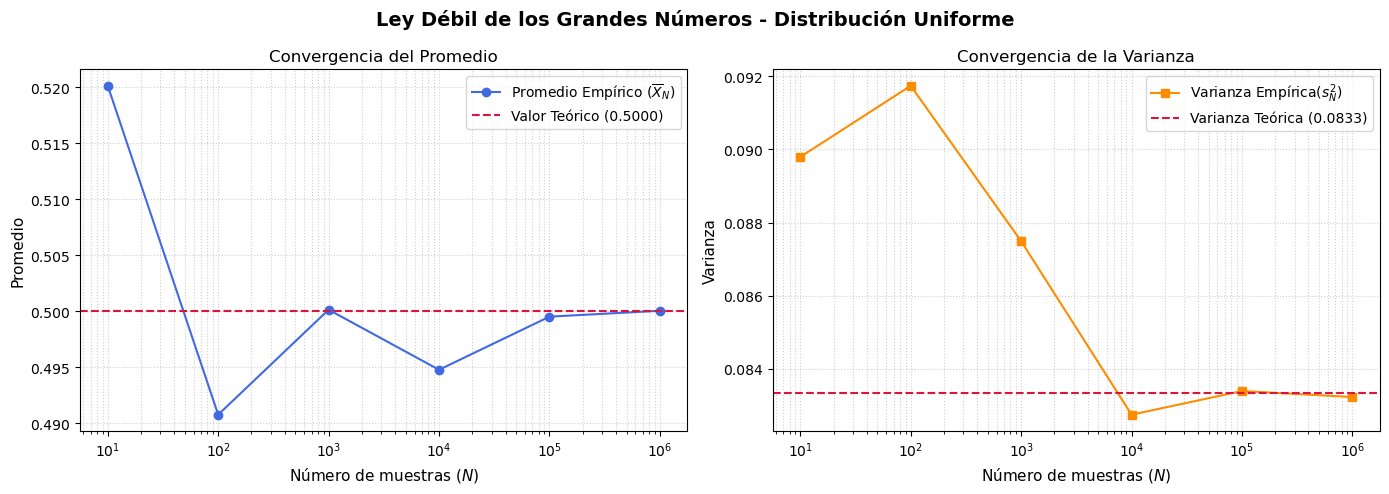

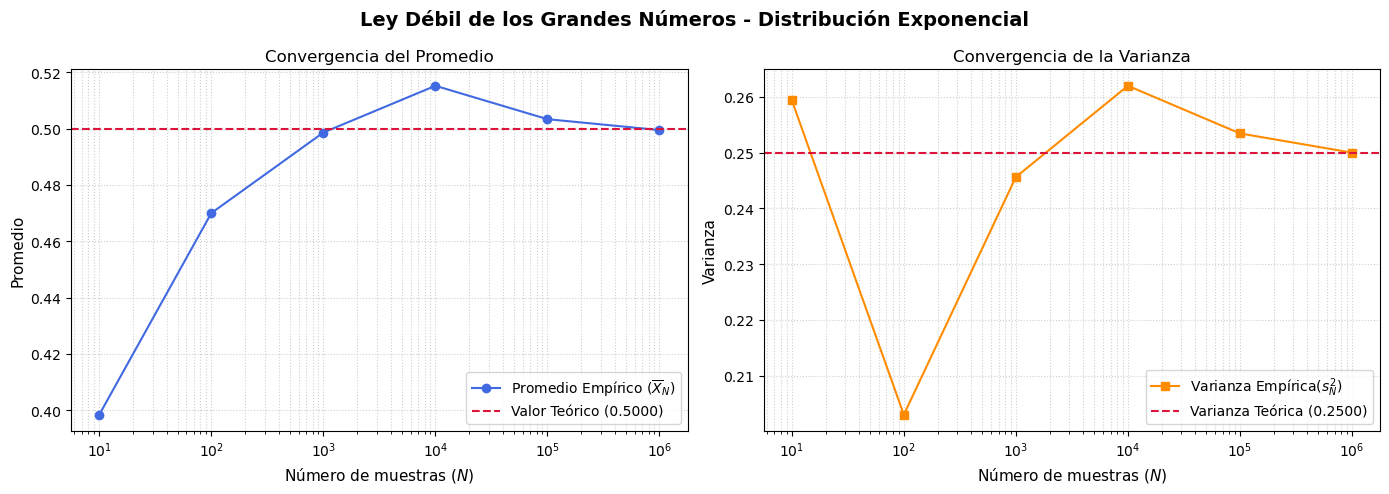

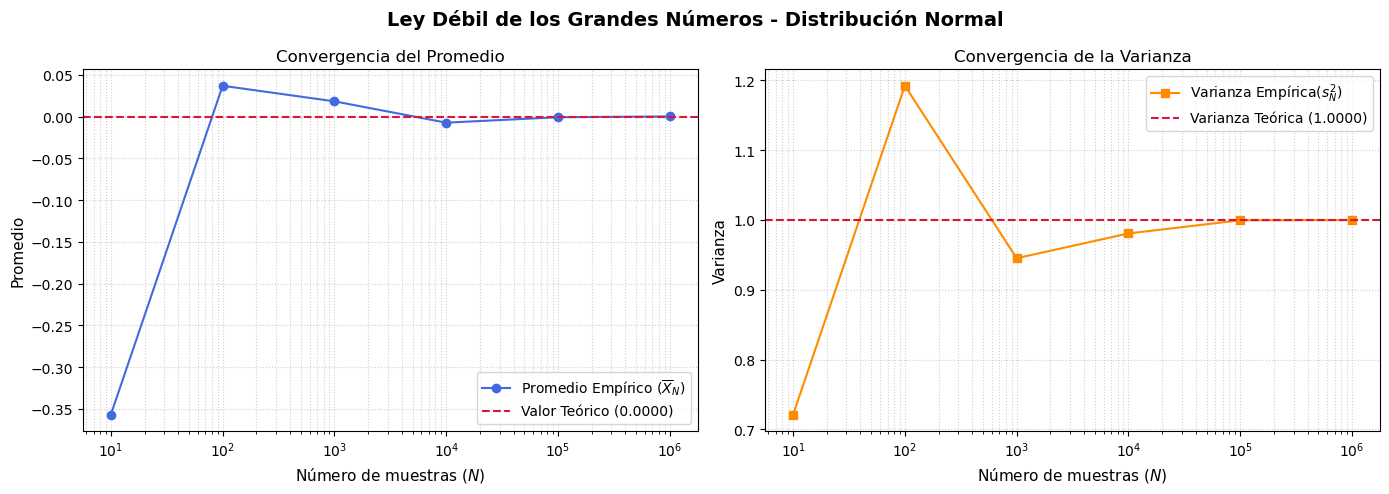

In [10]:
# Procedemos a definir los parámetros de las distribuciones

a, b = 0, 1
lambda_param = 2
mu, sigma = 0, 1
# Procedemos a generar los valores de N iteraciones

N_values = [10**1, 10**2, 10**3, 10**4, 10**5, 10**6]

# Y podemos colocar un diccionario para guardar los resultados numéricos de las tres distribuciones

resultados = {
    'Uniforme':{'emp_mean':[], 'emp_var':[], 'theo_mean': (a+b)/2, 'theo_var':(b-a)**2/12},
    'Exponencial':{'emp_mean':[], 'emp_var':[], 'theo_mean': 1/lambda_param, 'theo_var':1/lambda_param**2},
    'Normal':{'emp_mean':[], 'emp_var':[], 'theo_mean':mu, 'theo_var':sigma**2},
}

# Colocamos una semilla de reproducibilidad, en donde colocamos ahora invocamos a la librería numpy para esto

np.random.seed(42)

# Procedemos a colocar una simulación numérica y cálculo de promedios / varianzas empíricas

for N in N_values:
    # Con este bucle for, procedemos a generar muestras aleatorias para integrar nuestro método

    muestras_uniformes = np.random.uniform(a,b,N)
    muestras_exponencial = np.random.exponential(1/lambda_param, N) 
    muestras_normal = np.random.normal(mu, sigma, N)

    # Procedemos a colocar la distribución uniforme

    resultados['Uniforme']['emp_mean'].append(np.mean(muestras_uniformes))
    resultados['Uniforme']['emp_var'].append(np.var(muestras_uniformes))

    # Para nuestra distribución exponencial, colocamos ahora que:

    resultados['Exponencial']['emp_mean'].append(np.mean(muestras_exponencial))
    resultados['Exponencial']['emp_var'].append(np.var(muestras_exponencial))

    # Colocamos la distribución normal

    resultados['Normal']['emp_mean'].append(np.mean(muestras_normal))
    resultados['Normal']['emp_var'].append(np.var(muestras_normal))

# Procedemos a generar los gráficos claros de cada distribución para este caso

for dist_name, data in resultados.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
    fig.suptitle(f'Ley Débil de los Grandes Números - Distribución {dist_name}', fontsize=14, fontweight='bold')

    # Colocamos la gráfica de promedio empírico vs los valores N

    ax1.plot(N_values, data['emp_mean'], marker='o', color='royalblue', label='Promedio Empírico ($\overline{X}_N$)')
    ax1.axhline(y=data['theo_mean'], color='crimson', linestyle='--', label=f'Valor Teórico ({data["theo_mean"]:.4f})')
    ax1.set_xscale('log')
    ax1.set_xlabel('Número de muestras ($N$)', fontsize=11)
    ax1.set_ylabel('Promedio', fontsize=11)
    ax1.set_title('Convergencia del Promedio')
    ax1.grid(True, which="both", linestyle = ':', alpha=0.6)
    ax1.legend()

    # Realizamos la gráfica de Varianza Empírica contra los valores de N

    ax2.plot(N_values, data['emp_var'], marker='s', color='darkorange', label='Varianza Empírica($s_N^2$)')
    ax2.axhline(y=data['theo_var'], color='crimson', linestyle='--', label=f'Varianza Teórica ({data["theo_var"]:.4f})')
    ax2.set_xscale('log') # Escala logarítmica para el eje horizontal
    ax2.set_xlabel('Número de muestras ($N$)', fontsize=11)
    ax2.set_ylabel('Varianza', fontsize=11)
    ax2.set_title('Convergencia de la Varianza')
    ax2.grid(True, which='both', linestyle =':', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()




In [11]:
# Y colocamos una impresión para verificar numéricamente el output

print(f"{'Distribución':<15} | {'N':<8} | {'Media Emp.':<10} vs {'Media Teo.':<10} | {'Var Emp.':<10} vs {'Var Teo':<10}")
print("-" * 78)
for dist_name, data in resultados.items():
    for i, N in enumerate(N_values):
        print(f"{dist_name:<15} | {N:<8} | {data['emp_mean'][i]:.5f} vs {data['theo_mean']:.5f} | {data['emp_var'][i]:.5f} vs {data['theo_var']:.5f}")
    print("-" * 200)

Distribución    | N        | Media Emp. vs Media Teo. | Var Emp.   vs Var Teo   
------------------------------------------------------------------------------
Uniforme        | 10       | 0.52014 vs 0.50000 | 0.08979 vs 0.08333
Uniforme        | 100      | 0.49078 vs 0.50000 | 0.09174 vs 0.08333
Uniforme        | 1000     | 0.50015 vs 0.50000 | 0.08749 vs 0.08333
Uniforme        | 10000    | 0.49479 vs 0.50000 | 0.08274 vs 0.08333
Uniforme        | 100000   | 0.49953 vs 0.50000 | 0.08339 vs 0.08333
Uniforme        | 1000000  | 0.50006 vs 0.50000 | 0.08322 vs 0.08333
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Exponencial     | 10       | 0.39846 vs 0.50000 | 0.25944 vs 0.25000
Exponencial     | 100      | 0.46999 vs 0.50000 | 0.20298 vs 0.25000
Exponencial     | 1000     | 0.49858 vs 0.50000 | 0.24563 vs 0.25000
Exponencial     | 